In [1]:
import os
import glob
import warnings


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from scipy import io, stats
from random import sample


import utils.drl as utils
from utils.plots import *
from utils.data import *
from utils.stats_perform import *
from utils.path import PathConfig,FigureWithData,save_figure_pdf
from rl.agent import *
import rl.plots as rlplt

import random

# Set random seed
seed_value = 1234  # Or any integer you like
np.random.seed(seed_value)
random.seed(seed_value)
warnings.filterwarnings("ignore")

fig_dir = os.path.join('figures', 'figure_5')
data_fig_dir = os.path.join('data', 'source_data', 'figure_5')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)



## Habenula lesion data analysis

This notebook performs the  analysis of the Habenula lesion dataset performed in the manuscript:  *Romero Pinto, S., & Uchida, N. (2023). **Tonic dopamine and biases in value learning linked through a biologically inspired reinforcement learning model***

The dataset consists of electrophysiological recordgins of VTA dopamine neurons and the behavioral readouts  published originally in *Habenula Lesions Reveal that Multiple Mechanisms Underlie Dopamine Prediction Errors. Neuron, 87(6), 1304–1316 [https://doi.org/10.1016/j.neuron.2015.08.028*]

**Note:** To plot and use the present notebook the user needs to download the data inside `raw_data` folder of the OSF repository. Look at  `download_data` for the code to do this.

In [2]:
paths = PathConfig()
save_dir = paths.save_dir
g_dir = paths.g_dir
col_g = ['black','red']
groups = ['control','lesion']
nf = [45,44]
probs_cues = [10,50,90]
s = dict()
s['baselineWindow']      = [-1500, -500]  #% in units of milliseconds
s['psthWindow']          = [-1500, 4500]  #% in units of milliseconds
s['cueWindow']           = [0, 400]   # in units of milliseconds
s['traceWindow']         = [500, 2000]  #% in units of milliseconds
s['outcomeWindow']       = [2000, 2600] # % in units of milliseconds
s['outcomeWindowLate']       = [2200, 2600]  #% in units of milliseconds
s['outcomeWindowFreeLate']   = [200, 400]  #% in units of milliseconds
s['psthResolution']          = 2   #% in units of milliseconds
s['normalizeTo50']           = True # % when true, this will normalize the 50% responses for each cell according to the mean (across cells) of 50% responses in that animal.
s['smoothingTimeConst']      = 20;  #% 20 is what the eshel paper used (units of milliseconds)
s['interestingTrialTypes']   = np.arange(15)
s['maxTrialsPerType'] = 300
s['indeces'] = dict()
s['indeces']['puff80'] = [6,7]
s['indeces']['prob10']= [4,5]
s['indeces']['prob50'] = [2,3]
s['indeces']['prob90']= [0,1]
s['indeces']['freeRew'] = 8
s['indeces']['freePuff'] = 9
alpha_p = .05

loader_c = DataLoad(s)
data_path = os.path.join(g_dir, 'raw_data',groups[0])
data_path
file_list = glob.glob(data_path + '/*.pickle')
PSTH, PSTC, spikeRaster = loader_c.load_cells(file_list,response_type = 'spikes')
print('computing responses for '+ groups[0])
loader_c.compute_responses_re_baseline(PSTH)
PSTH_licks, PSTC_licks, lickRaster = loader_c.load_cells(file_list,response_type = 'licks')
_,_,_ =loader_c.compute_lick_responses(PSTH_licks)
loader_c.get_cells_same_day(file_list)

loader_l= DataLoad(s)
data_path = os.path.join(g_dir,'raw_data', groups[1])
file_list = glob.glob(data_path + '/*.pickle')
PSTH, PSTC, spikeRaster = loader_l.load_cells(file_list,response_type = 'spikes')
loader_l.compute_responses_re_baseline(PSTH)
PSTH_licks, PSTC_licks, lickRaster = loader_l.load_cells(file_list,response_type = 'licks')
_,_,_=loader_l.compute_lick_responses(PSTH_licks)
loader_l.get_cells_same_day(file_list)

Cell Number: 100%|██████████| 45/45 [00:12<00:00,  3.67it/s]


computing responses for control


Cell Number: 100%|██████████| 44/44 [00:06<00:00,  7.26it/s]


### Figure 5c
- Outcome responses 

The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_5/figure_5c.pdf
Saved data and stats to data/source_data/figure_5/figure_5c.txt


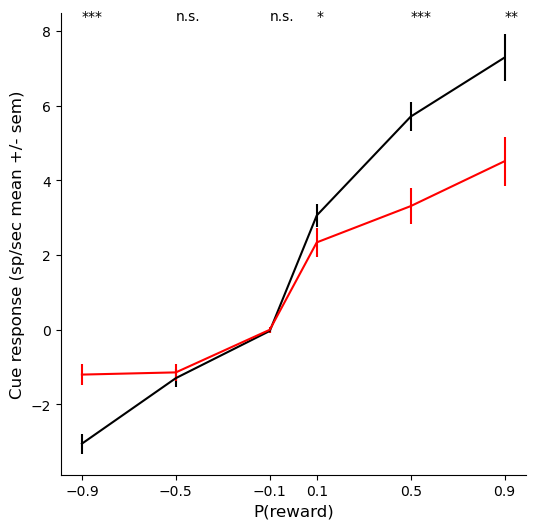

In [5]:
alpha_p = .05
mu_across_cells_c,sem_across_cells_c,per_cell_c = loader_c.compute_mu_responses_per_cue_outcome(loader_c.outcomeResponses)
mu_across_cells_l,sem_across_cells_l,per_cell_l = loader_l.compute_mu_responses_per_cue_outcome(loader_l.outcomeResponses)
groups_test = [[per_cell_c[ii,:],per_cell_l[ii,:]] for ii in range(per_cell_l.shape[0])]
name_suff = ['-90','-50','-10','10','50','90']
rpes_x = [-.9,-.5,-.1,.1,.5,.9]
name_preff = 'outcome'
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = True)
pvals = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].pvals.to_numpy()[0] for ig in range(6)])
stats_p = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].stats.to_numpy()[0] for ig in range(6)])
yy = np.max([mu_across_cells_c,mu_across_cells_l])+1
fig,ax = plt.subplots(figsize=(6,6))
ax.errorbar(rpes_x,mu_across_cells_c,sem_across_cells_c,color=col_g[0])
ax.errorbar(rpes_x,mu_across_cells_l,sem_across_cells_l,color=col_g[1])
[ax.text(rpes_x[ii],yy,get_pval_str(pv)) for (ii,pv) in enumerate(pvals)]
plot_config(ax,'P(reward)','Cue response (sp/sec mean +/- sem)',12,False)
ax.set_xticks(rpes_x)


# 1. Create the wrapper
fig_data_5c = FigureWithData(fig)

# 2. Add panel: Outcome responses across RPEs
panel_data = np.column_stack((
    rpes_x,
    mu_across_cells_c,
    sem_across_cells_c,
    mu_across_cells_l,
    sem_across_cells_l
))
panel_headers = ['RPE_value', 'Mean_Outcome_C', 'SEM_Outcome_C', 'Mean_Outcome_L', 'SEM_Outcome_L']
fig_data_5c.add_data(
    "Outcome responses across RPEs (mean ± SEM)",
    panel_data,
    panel_headers
)

# 3. Add stats (per RPE)
stat_array = np.column_stack((rpes_x, pvals, stats_p))
stat_headers = ['RPE_value', 'p_value', 'test_statistic']
fig_data_5c.add_stats(
    "Statistical tests (ranksum per RPE)",
    stat_array,
    stat_headers
)

# 4. Save everything
fig_data_5c.save(
    base_filename='figure_5c',
    folder_data= data_fig_dir,
    folder_figures=fig_dir
)


### Figure 5d
- Compute taus from single cells


Saved figure to figures/figure_5/figure_5d_leftpanel.pdf
Saved data and stats to data/source_data/figure_5/figure_5d_leftpanel.txt
The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_5/figure_5d_rightpanel.pdf
Saved data and stats to data/source_data/figure_5/figure_5d_rightpanel.txt


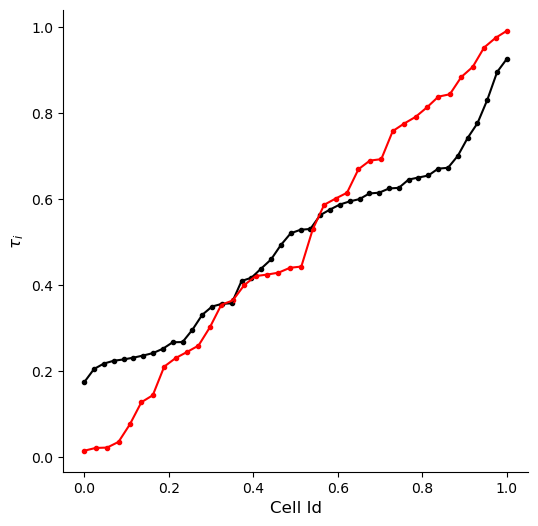

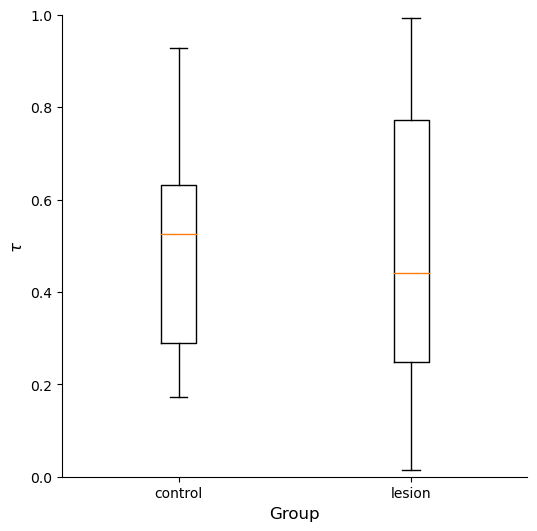

In [6]:
#%% Compute taus from firing rates:
indeces_resp = [loader_l.indeces_prob90[1],loader_l.indeces_prob50[1],loader_l.indeces_prob10[1],
                loader_l.indeces_prob90[0],loader_l.indeces_prob50[0],loader_l.indeces_prob10[0],]
# Format FR to: (n_cells,n_types,n_trials) 
per_cell_l = np.asarray([loader_l.outcomeResponses[:,ii,:] for ii in indeces_resp])
per_cell_c = np.asarray([loader_c.outcomeResponses[:,ii,:] for ii in indeces_resp])

#% =% Compute taus and zerocrossing poitns
method_zcross='count'
groups_resp = [per_cell_c,per_cell_l]
taus_v,id_disc,zcross_v,zcross_rpev,apos,aneg = [],[],[],[],[],[]
for iresp in groups_resp:
    per_cell = iresp.copy().transpose(1,0,2)
    utility_axis = np.floor(np.nanmean(np.nanmean(per_cell,axis=2),axis=0)*1000)/1000
    m = [utils.compute_drl_metrics(per_cell[i_cell,:,:],utility_axis,method_zcross) for i_cell in range(per_cell.shape[0])]
    taus_,alpha_pos,alpha_neg,zcross_util,zcross_rpe,i_disc = utils.extract_metrics(m,[utility_axis for _ in range(len(m))],rpes_x)
    taus_v.append(taus_)
    zcross_v.append(zcross_util)
    apos.append(alpha_pos)
    aneg.append(alpha_neg)
    zcross_rpev.append(zcross_rpe)
    id_disc.append(i_disc)
#% % Figure 5d:
fig,ax = plt.subplots(figsize=(6,6))
ax.plot(np.linspace(0,1,len(np.sort(taus_v[0]))),np.sort(taus_v[0]),'.',color='black')
ax.plot(np.linspace(0,1,len(np.sort(taus_v[1]))),np.sort(taus_v[1]),'.',color='red')
ax.plot(np.linspace(0,1,len(np.sort(taus_v[0]))),np.sort(taus_v[0]),color='black')
ax.plot(np.linspace(0,1,len(np.sort(taus_v[1]))),np.sort(taus_v[1]),color='red')
plot_config(ax,'Cell Id',r'$\tau_i$',12,False)

# 1. Create the wrapper for left panel
fig_data_5d_left = FigureWithData(fig)  # your sorted taus fig

# 2. Add sorted taus
taus_sorted_c = np.sort(taus_v[0])
taus_sorted_l = np.sort(taus_v[1])
taus_cumulative = np.linspace(0, 1, len(taus_sorted_c))
taus_l_cumulative = np.linspace(0, 1, len(taus_sorted_l))

fig_data_5d_left.add_data(
    "Sorted taus control ",
    taus_sorted_c,
    'Taus_control'
)

fig_data_5d_left.add_data(
    "Sorted taus lesion ",
    taus_sorted_l,
    'Taus_lesion'
)


# 3. Save (left panel)
fig_data_5d_left.save(
    base_filename='figure_5d_leftpanel',
    folder_data= data_fig_dir,
    folder_figures= fig_dir
)




fig,ax = plt.subplots(figsize=(6,6))
ax.boxplot([taus_v[0],taus_v[1]])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()
ax.set_xlabel('Group',fontsize=12)
ax.set_ylabel(r'$\tau$',fontsize=12)
ax.set_xticklabels(groups)
ax.set_ylim([0,1])


# Test for means different from 0.5:
for (ix,itau) in enumerate(taus_v):
    res_mean = compute_monte_carlo(itau-.5,statistic_mean,int(len(itau)),rvs_type = 'students-t',alternative='greater',batch =100)
    new_row =  pd.DataFrame({   'name_test':['MC_tstat_mean_taus'],  'pvals':[res_mean.pvalue],'stats':[res_mean.statistic],
                                    'stat_name': ['greater'],  'group_nb':[ix],'group_name':[ groups[ix]] ,'N':[len(itau)]  })
    tests_pd = pd.concat([new_row,tests_pd.loc[:]]).reset_index(drop=True)
# Test for difference between distributions : 
groups_test =  [[taus_v[0],taus_v[1]]]
name_suff = ['taus']
name_preff = 'tstat'
alternative = 'less'
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = False ,tests_pd=tests_pd,alternative=alternative)

# 1. Create the wrapper for right panel
fig_data_5d_right = FigureWithData(fig)  # your boxplot fig

# 2. Add individual taus for boxplots
fig_data_5d_right.add_data(
    "Tau distributions - control",
    taus_v[0],
    'taus_control'
)
fig_data_5d_right.add_data(
    "Tau distributions - lesion",
    taus_v[1],
    'taus_lesion'
)

# 3. Add MC stats
# (you already computed Monte Carlo test for means vs 0.5 and group differences)
# Here I assume you already updated `tests_pd`

# Optionally, extract the relevant rows
stats_rows = tests_pd[(tests_pd['name_test'].str.contains('MC_tstat_mean_taus')) | (tests_pd['group_name'].str.contains('taus'))]

stat_array = np.column_stack((
    stats_rows['group_nb'].to_numpy(),
    stats_rows['pvals'].to_numpy(),
    stats_rows['stats'].to_numpy()
))
stat_headers = ['Group_index', 'p_value', 'statistic']

fig_data_5d_right.add_stats(
    "Monte Carlo tests for taus (means and group difference)",
    stat_array,
    stat_headers
)

# 4. Save (right panel)
fig_data_5d_right.save(
    base_filename='figure_5d_rightpanel',
    folder_data= data_fig_dir,
    folder_figures= fig_dir
)
tests_pd.to_excel("analysis/stats/Fig5.xlsx")

**Perform risk-sensitive RL simulations with :**
- $\tau s $ derived from dopamine firing rates from Lhb lesion dataset

`eta_nosampling_nodistr_`: Risk- sensitive TD learning  (TD learning not DRL using the mean across  $\tau s $  )
$$
\delta_{t} = r_t + \gamma \cdot V(s_{t+1}) - V(s_t)\\
\hat{\delta}_{t} ~~ = ~~~\hat{\tau} \cdot \delta_{t} ~~~... ~~~\text{if} ~ \delta_{t} >0 \\
\hat{\delta}_{t}  =(1-\hat{\tau}) \cdot \delta_{t} ~~~... ~~~\text{if} ~ \delta_{t} \leq 0
$$

- Where $ \hat{\tau}$ is the mean of the $\tau_i$ across the population of each group
- Update of value:
$$
P(s_t) \leftarrow P(s_t) + \eta \cdot |\hat{\delta}_i(t)| - \beta \cdot P(s_t) ~~~... ~~~\text{if} ~ \delta_{t} >0\\
N(s_t) \leftarrow N(s_t) + (1-\eta) \cdot |\hat{\delta}_i(t)| - \beta \cdot N(s_t) ~~~... ~~~\text{if} ~ \delta_{t} \leq 0 \\
\hat{V}(s_t) = P(s_t) - N(s_t)
$$  


In [15]:
simulation_type = 'eta_sampling_' 
g_names = ['control','lesion']
simulations_dir = os.path.join('data','local','analysis','rl_simulations')

beta_v = [0.0] 
for ieps in np.arange(len(beta_v)):
    epsilon_ = beta_v[ieps]
    for i_group in  np.arange(2):
        results_v = list()
        n_iterations = 10
        etas = 0.5 *np.ones((n_iterations))
        taus_= np.sort(taus_v[i_group])
        taus_ = taus_[(taus_>0)*(taus_<1)]
        #% %
        for ie in np.arange(n_iterations):
            if not  np.isnan(etas[ie] ):
                s = dict()
                s['agent'] = dict()
                s['task'] = dict()
                if simulation_type == 'eta_nosampling_' :
                    s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
                    s['agent']['do_sampling'] = False
                elif simulation_type == 'eta_nosampling_nodistr_': 
                    s['agent']['taus'] =   np.asarray([np.nanmean(taus_) ]) # needs to be array 
                    s['agent']['do_sampling'] = False
                elif simulation_type == 'eta_sampling_': 
                    s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
                    s['agent']['do_sampling'] = True

                s['agent']['eta'] = etas[ie]
                print('Processing for eta = '+ str(etas[ie]) + 'epsilon = '+str(epsilon_) + '|| ' +str(ie) + ' of '+str(n_iterations))
                s['agent']['str_agent'] = ['Eta_' + str(etas[ie])]#,'neutral','optimistic']
                s['agent']['epsilon'] = epsilon_
                s['agent']['base_alpha'] = 1 
                s['agent']['gamma'] = 0.99
                
                s['agent']['d1_d2'] = True
                s['task']['prob'] = [[.1, .9],[.5, .5],[.9, .1] ,[.8, .2]]
                s['task']['mags'] = [[1, 0],[1, 0],[1, 0] ,[-1, 0]]
                s['task']['percent_per_cs'] = 1/len(s['task']['mags'])*np.ones((len(s['task']['mags']),1))
                s['task']['cs_id'] = [[0,0],[1,1],[2,2],[3,3]]
                s['task']['str_cs'] = [ '10%','50%','90%','80%Puff']
                s['task']['str_task'] = 'drl_6odor'
                s['task']['n_trials'] = 2000
                s['task']['cue_onset'] = 1
                s['task']['cue_dur'] = 1
                s['task']['rew_onset'] = 3
                s['task']['iti_dur'] = 1
                s['task']['n_iterations'] = 1
                s['task']['seed'] = seed_value

                s['task']['type'] = 'cue_reward'

                agent = TDLearning(s)
                agent.initialize_results()
                agent.run_task()
                agent.reformat_results()
                save_dic = dict()
                results = dict()
                save_vars = ['distribution_trials_full', 'distribution_g_trials_full', 'distribution_ng_trials_full',  'deltas_trials_full', 
                             'distribution_ng_trials', 'distribution_g_trials', 'distribution_trials','deltas_trials']
                for ivar in save_vars:
                    temp = agent.results[ivar]
                    if len(temp.shape)==4:
                        id_end = np.argwhere(np.nansum(temp,axis=(0,1,2))==0).flatten()[0]
                        temp = temp[:,:,:,:id_end]
                    results[ivar] = temp
                save_vars = ['distribution','distribution_g','distribution_ng','samp_distribution','deltas','deltas_trials_raw','distribution_std']
                new_dict = vars(agent)
                for ivar in save_vars:
                    results[ivar] = new_dict[ivar]
                agent_dict = dict()
                save_vars=['taus', 'eta', 'str_agent', 'epsilon', 'base_alpha', 'do_sampling', 'gamma',
                            'n_cells', 'task_type', 'n_deliv_rew', 'deliv_rew', 'deliv_cs', 'trial_length', 
                            'n_trials', 'cs_vector', 'us_vector', 'id_states_per_cs', 'n_types', 'n_tr_max', 
                            'i_step_per_cs']
                for ivar in save_vars:
                    agent_dict[ivar] = new_dict[ivar]
                save_dic['results'] = results
                save_dic['agent'] = agent_dict
                save_dic['task'] = vars(agent.task)
                save_dic['eta'] = etas
                np.save(os.path.join(simulations_dir,'results_sim_type_'+ simulation_type 
                + 'eps_' + str(epsilon_).replace('.','_')+'_'+g_names[i_group]+'_iteration_'+str(ie) ),save_dic)
                print('Saving ' + simulations_dir,'results_sim_type_'+simulation_type 
                + 'eps_' + str(epsilon_).replace('.','_')+'_'+g_names[i_group]+'_iteration_'+str(ie) )

Processing for eta = 0.5epsilon = 0.0|| 0 of 10


KeyboardInterrupt: 

Saved figure to figures/figure_5/figure_5e_left.pdf
Saved figure to figures/figure_5/figure_5e_right.pdf


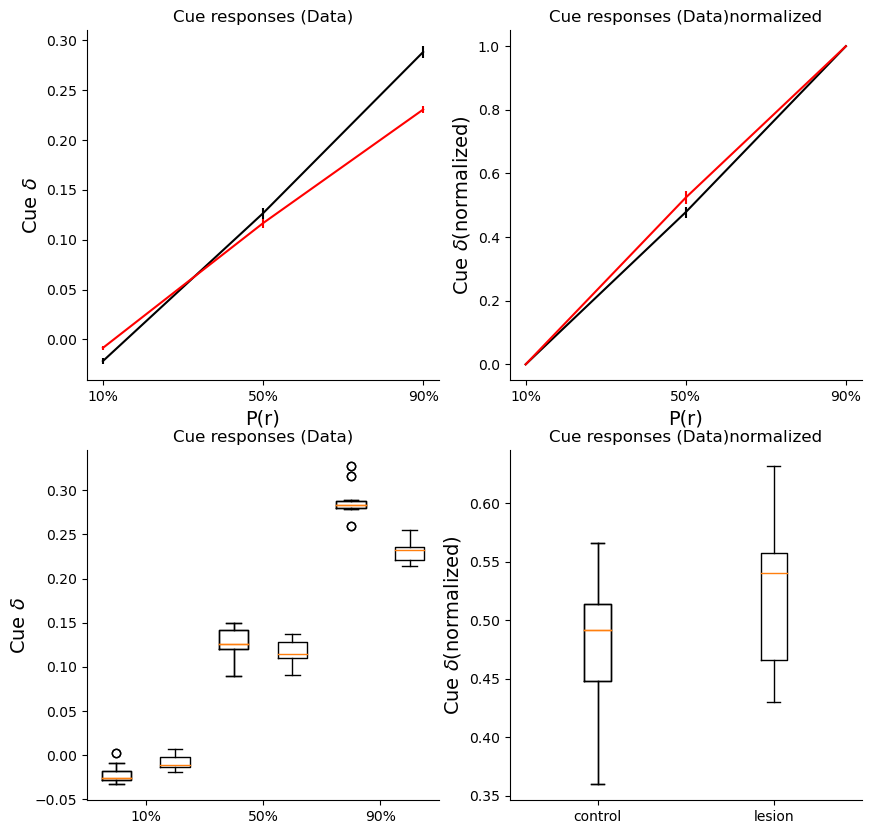

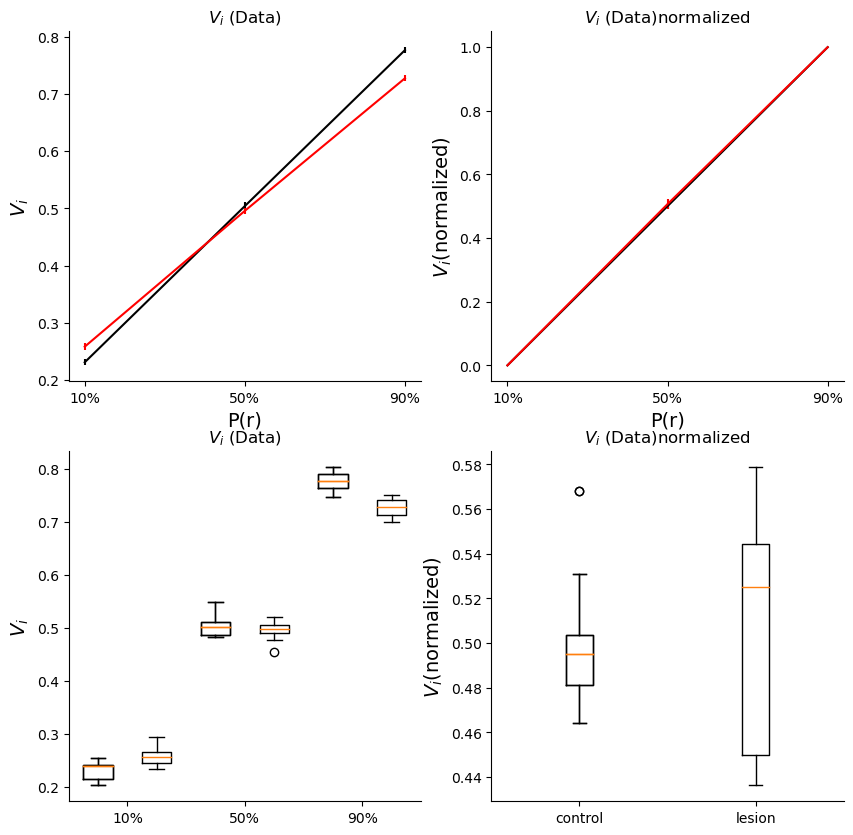

In [16]:
simulation_type = 'eta_sampling_' 

file_type = 'results_sim_type_' + simulation_type + 'eps_'
cs_names = ['10%','50%','90%']
i_group = 0
ieps=0
taus_=np.sort(taus_v[i_group])
eta_ = .5
taus_ = taus_[(taus_>0)*(taus_<1)]
epsilon_ = beta_v[ieps]
agent = create_instance_agent_pav_task(taus_v[1],eta_,epsilon_)
colors_g = ['black','red']
mu_ieps=dict()
mu_ieps['cue_response_mean']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_n']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_n']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_n_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_n_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['baseline_vi_mean']=   np.nan*np.ones((len(beta_v),2))
mu_ieps['baseline_vi_mean_std']=   np.nan*np.ones((len(beta_v),2))
for i_eps in range(len(beta_v)):
    eps = beta_v[i_eps]
    eps_str = str(eps).replace('.','_')
    file_list = glob.glob(os.path.join(simulations_dir ,file_type + eps_str +'_control_*'))
    results_control = [np.load(ifile, allow_pickle=True).flatten()[0] for ifile in file_list]
    file_list = glob.glob(os.path.join(simulations_dir ,file_type + eps_str +'_lesion_*'))
    results_lesion = [np.load(ifile, allow_pickle=True).flatten()[0] for ifile in file_list]
    results_l = [rr for rr in results_lesion if len(rr)>0 ]
    results_c = [rr for rr in results_control if len(rr)>0 ]
    #% % Plot means 
    results_v=[results_c,results_l]
    evtype = 'mean'
    vars_n = ['deltas_trials_full','distribution_trials_full']
    save_titles = ['cue_response_mean','vi_mean']
    y_labels = [r'Cue $\delta$',r'$V_i$']
    id_states = [1,3]
    
    id_cs_plot = np.arange(3)
    id_iter_plot = np.arange(0,len(results_c))
    plot_titles = [r'Cue responses (Data)',r'$V_i$ (Data)']
    fig,ax = rlplt.plot_mean_per_trial_batch_iterations(agent,results_v,vars_n,id_states,save_titles,plot_titles,y_labels,cs_names,g_names,
                                         id_cs_plot,id_iter_plot,simulation_type,[],colors_g,evtype =evtype)    
    save_figure_pdf(fig[0],'figure_5e_left',folder =fig_dir)
    save_figure_pdf(fig[1],'figure_5e_right',folder =fig_dir)